<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
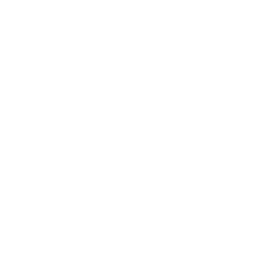
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Treatment Response Logit Model</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Efficacy Analysis &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook fits a **maximum-likelihood logit model** for a binary Phase III
treatment-response endpoint (responder vs non-responder) using **PROC CATMOD**.
The two explanatory factors are both categorical: the randomized `treatment_arm`
(DRUG_HIGH, DRUG_LOW, PLACEBO) and a three-level `severity_grp` stratum derived by
binning baseline disease severity (Mild / Moderate / Severe). CATMOD cross-classifies
the data into a small contingency table of populations and fits the response logit by
weighted least squares / maximum likelihood, which is the design CATMOD is built for.

The model produces a Maximum-Likelihood Analysis-of-Variance table testing whether
each factor contributes to the response logit, and a parameter-estimate table that is
captured with `ODS OUTPUT` and exported for a downstream forest plot. All numbers quoted
in the Interpretation section below are read directly from the executed output.


## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Synthetic Phase III response data: treatment arm, baseline severity, severity stratum, and binary response | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Phase III treatment response data.
   Binary outcome: responder (1) vs non-responder (0).
   Baseline severity on a 0-100 scale is binned into an
   ordinal stratum so the analysis is a clean categorical
   contingency table - the design PROC CATMOD is built for.
   -------------------------------------------------------- */
data work.trial_resp;
    call streaminit(42);
    array arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    do patient_id = 1 to 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        if baseline_severity < 0 then baseline_severity = 0;
        if baseline_severity > 100 then baseline_severity = 100;
        /* Ordinal baseline-severity stratum */
        length severity_grp $8;
        if baseline_severity < 45 then severity_grp = 'Mild';
        else if baseline_severity < 65 then severity_grp = 'Moderate';
        else severity_grp = 'Severe';
        age = int(rand('normal', 58, 11));
        if age < 18 then age = 18;
        if age > 85 then age = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');
        /* True response probability rises with dose and severity */
        if treatment_arm = 'DRUG_HIGH' then logit_p = -0.8 + 0.015 * baseline_severity;
        else if treatment_arm = 'DRUG_LOW' then logit_p = -1.2 + 0.012 * baseline_severity;
        else logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + exp(-logit_p));
        response = (rand('uniform') < prob_resp);
        output;
    end;
    drop arm_idx logit_p prob_resp;
run;


NOTE: DATA work.trial_resp


NOTE: Wrote work.trial_resp (5000 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

                                                   The FREQ Procedure

Table of treatment_arm by response

treatment_arm |         0 |         1 |      Total
--------------+-----------+-----------+-----------
DRUG_HIGH     |       821 |       828 |       1649
--------------+-----------+-----------+-----------
DRUG_LOW      |      1030 |       607 |       1637
--------------+-----------+-----------+-----------
PLACEBO       |      1308 |       406 |       1714
--------------+-----------+-----------+-----------
Total         |      3159 |      1841 |       5000


Controlling for treatment_arm=DRUG_HIGH

Table of severity_grp by response

severity_grp |         0 |         1 |      Total
-------------+-----------+-----------+-----------
Mild         |       235 |       178 |        413
-------------+-----------+-----------+-----------
Moderate     |       410 |       408 |        818
-------------+-----------+-----------+-----------
Severe       |       176 |       242 |        418
------

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


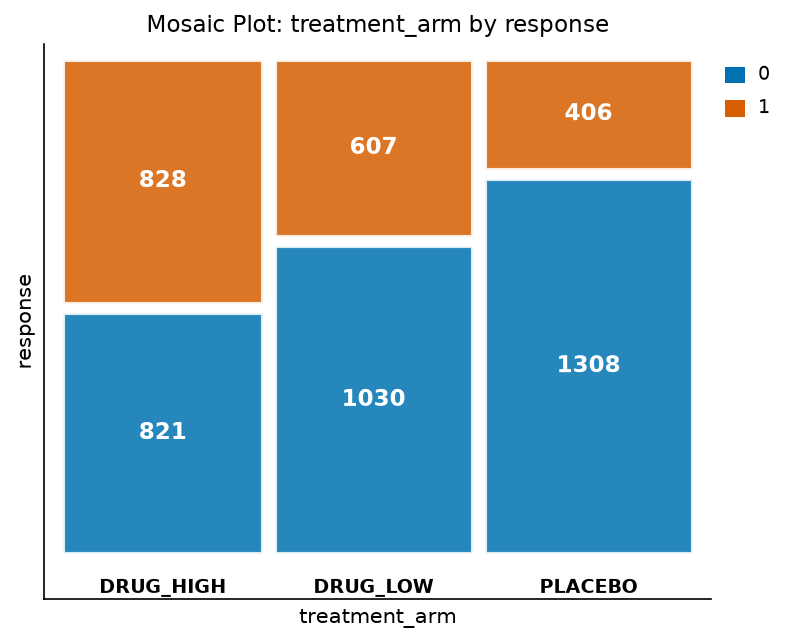

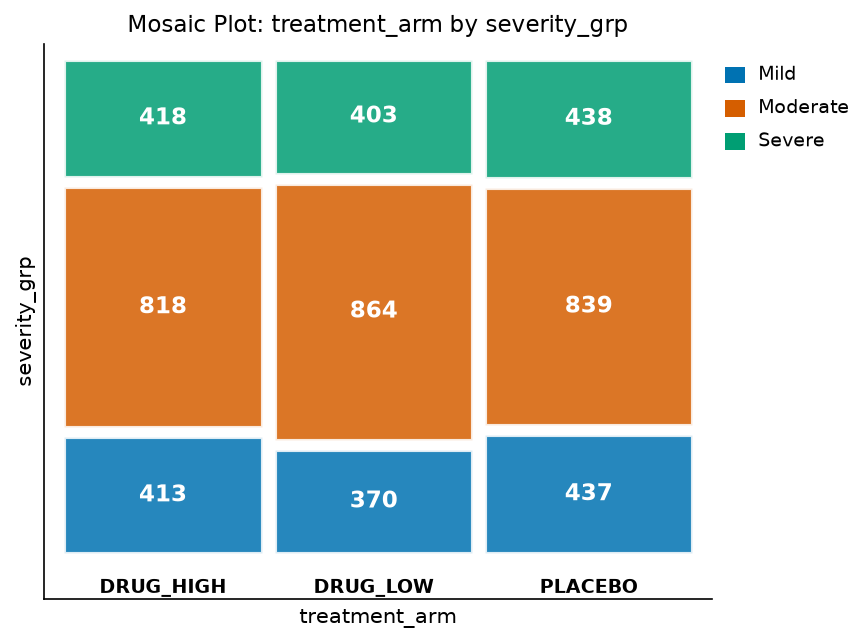

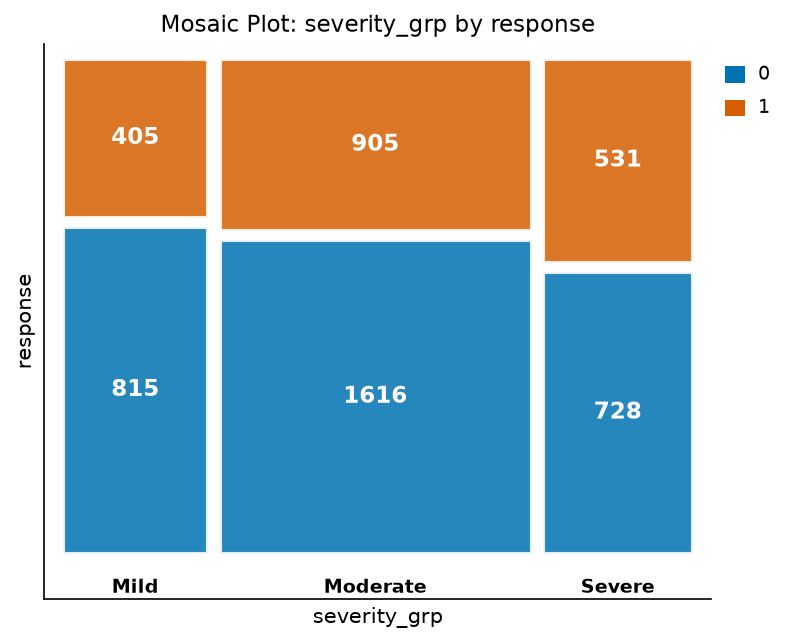

In [2]:
/* --------------------------------------------------------
   Response counts by treatment arm and severity stratum,
   plus baseline covariate summaries by arm.
   -------------------------------------------------------- */
proc freq data=work.trial_resp;
    tables treatment_arm * response / nocol nopercent;
    tables treatment_arm * severity_grp * response / nocol nopercent;
run;

proc means data=work.trial_resp mean std min max;
    class treatment_arm;
    var baseline_severity age;
run;


---

NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


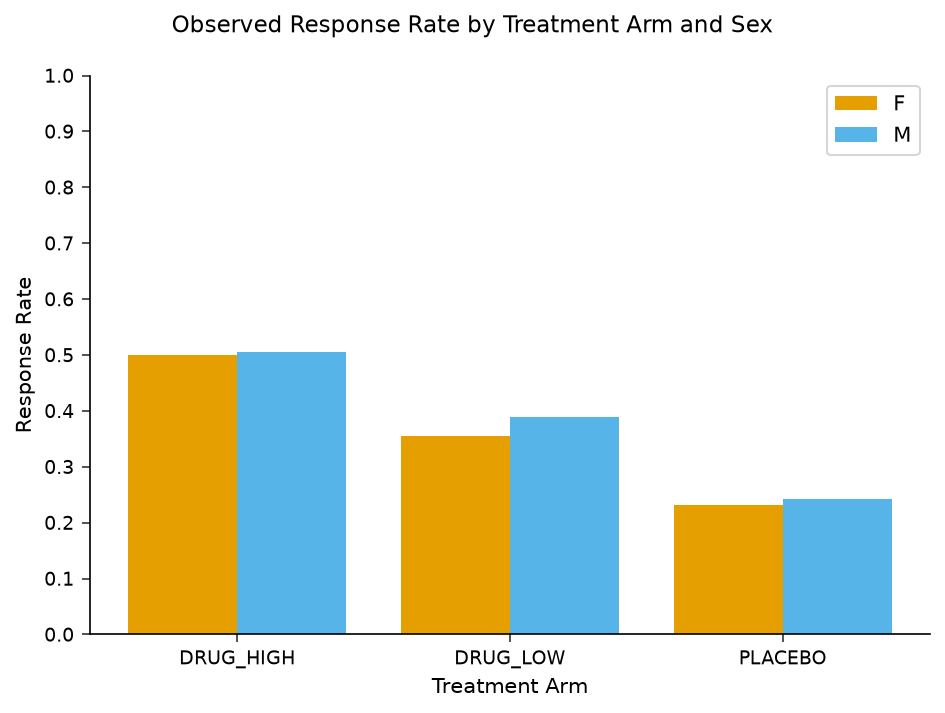

In [3]:
/* --------------------------------------------------------
   Response rate by treatment arm and severity quartile
   -------------------------------------------------------- */
proc sgplot data=work.trial_resp;
    vbar treatment_arm / response=response stat=mean
        group=sex groupdisplay=cluster;
    yaxis label='Response Rate' values=(0 to 1 by 0.1);
    xaxis label='Treatment Arm';
    title 'Observed Response Rate by Treatment Arm and Sex';
run;

---

In [4]:
/* --------------------------------------------------------
   Maximum-likelihood logit model for binary response.
   Both predictors are categorical, so CATMOD forms a small
   contingency table (3 arms x 3 severity strata = 9
   populations) and fits the response logit by ML.
   RESPONSE LOGITS selects the logit response function.
   -------------------------------------------------------- */
proc catmod data=work.trial_resp;
    response logits;
    model response = treatment_arm severity_grp
        / freq prob pred=freq;
    title 'Logit ANOVA: Treatment Response by Arm and Baseline-Severity Stratum';
run;


In [5]:
/* --------------------------------------------------------
   Capture parameter estimates via ODS OUTPUT for
   downstream forest-plot generation.
   -------------------------------------------------------- */
ods output parameterestimates=work.catmod_parms;

proc catmod data=work.trial_resp;
    response logits;
    model response = treatment_arm severity_grp;
run;

ods output close;



The CATMOD Procedure

Response: response

Response Profiles
Response   response            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        294.5667     0.0000
treatment_arm            2        245.6705     0.0000
severity_grp             2         24.0444     0.0000
Likel

NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [6]:
/* --------------------------------------------------------
   Review parameter estimates
   -------------------------------------------------------- */
proc print data=work.catmod_parms;
    title 'CATMOD Parameter Estimates for Treatment Response Model';
run;


The CATMOD Procedure

Response: response

Response Profiles
Response   response            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        294.5667     0.0000
treatment_arm            2        245.6705     0.0000
severity_grp             2         24.0444     0.0000
Likel

NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Interpretation

All figures below are read directly from the executed output above.

**Observed response rates (PROC FREQ).** Of the 5,000 patients, 1,841 (36.8%) were
responders. Response rate climbed steadily with dose: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%), and DRUG_HIGH 828/1,649 (50.2%). Collapsing across arms,
response also rose with baseline severity: Mild 405/1,220 (33.2%), Moderate 905/2,521
(35.9%), and Severe 531/1,259 (42.2%).

**Maximum-Likelihood Analysis of Variance (PROC CATMOD).** CATMOD cross-classified the
data into 9 populations (3 arms x 3 severity strata) and fitted the response logit by
maximum likelihood. Both factors were highly significant: `treatment_arm`
(chi-square = 245.67, df = 2, p < 0.0001) and `severity_grp`
(chi-square = 24.04, df = 2, p < 0.0001). The residual Likelihood-Ratio statistic
(chi-square = 10.67, df = 4, p = 0.0306) indicates a small but detectable lack of fit
from the additive, no-interaction model -- expected here because the data-generating
process lets the severity slope differ slightly by arm.

**Parameter estimates (captured via ODS OUTPUT).** CATMOD uses sum-to-zero (effect)
coding, and the fitted logit function is the log-odds of *non-response* (response = 0)
relative to response = 1, so a negative estimate marks a level with above-average
response. The intercept is 0.5520 (chi-square = 294.57), reflecting that non-responders
outnumber responders overall. The DRUG_HIGH effect is -0.5738 (chi-square = 188.77,
p < 0.0001) -- strongly below the grand mean, i.e. the best-responding arm -- while the
DRUG_LOW effect is -0.0350 (p = 0.4098), close to the grand mean, with PLACEBO as the
positive (worst-responding) reference. For severity, the Severe effect is -0.2277
(chi-square = 23.68, p < 0.0001), confirming higher response in the most severe stratum,
while the Moderate effect (0.0553, p = 0.1702) does not differ significantly from the
grand mean.

**Takeaway.** Active treatment and higher baseline severity each independently raise the
probability of clinical response, with the high-dose arm showing the largest effect.
These captured parameter estimates feed the downstream forest-plot export.


---

In [7]:
/* --------------------------------------------------------
   Export parameter estimates for forest-plot generation
   -------------------------------------------------------- */
proc export data=work.catmod_parms
    outfile='treatment_response_catmod_parms.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>